# Phase 1 Data QC: Final Feature Stack

**Objective**: Verify the integrity, physical validity, and spatial alignment of the final feature stack before Phase 2.

**Steps**:
1. **Load Data**: Confirm all files exist.
2. **Mechanical Audit**: CRS, Shape, Dtypes, Ranges (Unique values for masks).
3. **Physical Logic**: Test scientific assumptions (Water=Dark, Sand=Bright).
4. **Visual Check**: Maps and Correlations.

In [6]:
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Config
BASE_DIR = Path("../../")
FINAL_DIR = BASE_DIR / "data" / "final" / "phase1_features"

# Load Registry of file paths
files = sorted(list(FINAL_DIR.glob("*.tif")))
print(f"Found {len(files)} files in {FINAL_DIR.resolve()}")

Found 9 files in C:\Users\nithi\Desktop\Uni_Stuff\Y3\FYP\data\final\phase1_features


## Step 2: Mechanical & Statistical Audit
Goal: Ensure the 'Contract' (CRS, Size) is met and values are within expected ranges.

In [7]:
records = []
stack_arrays = {}

for f in files:
    with rasterio.open(f) as src:
        name = f.name
        # Store for later steps
        data = src.read(1)
        stack_arrays[name] = data
        
        # Identify type - put as mask if mask in the name or the datatype is int
        is_mask = 'mask' in name or 'uint8' in str(src.profile['dtype'])

        # Handle Nodata
        nodata = src.nodata
        if nodata is not None:
            valid_mask = (data != nodata)
            if np.issubdtype(data.dtype, np.floating):
                valid_mask = valid_mask & (~np.isnan(data))
        else:
            # If there is no 'no data' value avaialble assume all to be valid
            valid_mask = np.ones_like(data, dtype=bool)
            
        valid_data = data[valid_mask]
        
        if is_mask:
            uniques = np.unique(valid_data)
            if len(uniques) > 5:
                stats_str = f"Unique: {uniques[:5]}..."
            else:
                stats_str = f"Unique: {uniques}"
        else:
            if valid_data.size > 0:
                dmin = float(valid_data.min())
                dmax = float(valid_data.max())
                dmean = float(valid_data.mean())
                stats_str = f"Mean: {dmean:.2f} (Range: {dmin:.2f}-{dmax:.2f})"
            else:
                dmin, dmax, dmean = (None, None, None)
                stats_str = "Empty / All Nodata"
        
        stats = {
            "File": name,
            "CRS": src.crs.to_string(),
            "Size": f"{src.width}x{src.height}",
            "Dtype": src.profile['dtype'],
            "Stats": stats_str,
            "Valid%": (valid_data.size / data.size) * 100 # Percentage of the map that is actual data.
        }
        records.append(stats)

df_mech = pd.DataFrame(records)
df_mech

,File,CRS,Size,Dtype,Stats,Valid%
0,albedo_30m.tif,EPSG:32640,7691x7841,float32,Mean: 0.32 (Range: 0.09-1.03),11.233639
1,bsi_30m.tif,EPSG:32640,7691x7841,float32,Mean: 0.06 (Range: -0.29-0.30),11.233639
2,building_density_30m.tif,EPSG:32640,7691x7841,float32,Mean: 0.07 (Range: 0.00-1.00),3.430191
3,ndvi_30m.tif,EPSG:32640,7691x7841,float32,Mean: 0.02 (Range: -0.31-0.67),11.233639
4,road_density_30m.tif,EPSG:32640,7691x7841,float32,Mean: 0.04 (Range: 0.00-1.00),3.430191
5,sand_mask_30m.tif,EPSG:32640,7691x7841,uint8,Unique: [1],1.182287
6,urban_mask_30m.tif,EPSG:32640,7691x7841,uint8,Unique: [1],3.430191
7,water_mask_full_30m.tif,EPSG:32640,7691x7841,uint8,Unique: [1],4.679489
8,water_mask_urban_30m.tif,EPSG:32640,7691x7841,uint8,Unique: [1],1.035000


## Step 3: Physical Logic Verification
Goal: Test if the classifications make physical sense.

1. **Water Check**: Pixels in `water_mask_urban` should have Low NDVI and Low Albedo.
2. **Sand Check**: Pixels in `sand_mask` should have High Albedo and Low NDVI.
3. **Urban Boundary**: Pixels *outside* `urban_mask` should have Building Density == 0.

In [8]:
# Load specific masks and layers
if 'water_mask_urban_30m.tif' in stack_arrays:
    water = stack_arrays['water_mask_urban_30m.tif'] == 1
    n_water = water.sum()
    
    if n_water > 0:
        w_ndvi = stack_arrays['ndvi_30m.tif'][water]
        w_alb = stack_arrays['albedo_30m.tif'][water]
        
        # Handle NaNs and Nodata (-9999)
        w_ndvi = w_ndvi[(w_ndvi != -9999) & (~np.isnan(w_ndvi))]
        w_alb = w_alb[(w_alb != -9999) & (~np.isnan(w_alb))]
        
        print(f"WATER PIXELS (n={n_water} mask, {w_ndvi.size} valid):")
        print(f"  Mean NDVI:   {w_ndvi.mean():.4f} (Expected < 0.1)")
        print(f"  Mean Albedo: {w_alb.mean():.4f} (Expected < 0.2)")
    else:
        print("WATER PIXELS: None found")

if 'sand_mask_30m.tif' in stack_arrays:
    sand = stack_arrays['sand_mask_30m.tif'] == 1
    n_sand = sand.sum()
    if n_sand > 0:
        s_ndvi = stack_arrays['ndvi_30m.tif'][sand]
        s_alb = stack_arrays['albedo_30m.tif'][sand]
        
        s_ndvi = s_ndvi[(s_ndvi != -9999) & (~np.isnan(s_ndvi))]
        s_alb = s_alb[(s_alb != -9999) & (~np.isnan(s_alb))]
        
        print(f"\nSAND PIXELS (n={n_sand} mask, {s_ndvi.size} valid):")
        print(f"  Mean NDVI:   {s_ndvi.mean():.4f} (Expected < 0.15)")
        print(f"  Mean Albedo: {s_alb.mean():.4f} (Expected > 0.25)")

if 'urban_mask_30m.tif' in stack_arrays and 'building_density_30m.tif' in stack_arrays:
    urban = stack_arrays['urban_mask_30m.tif'] == 1
    outside_urban = (~urban)
    b_out = stack_arrays['building_density_30m.tif'][outside_urban]
    
    # Ignore -9999 and NaNs
    b_out = b_out[(b_out != -9999) & (b_out >= 0) & (~np.isnan(b_out))]
    
    print(f"\nOUTSIDE URBAN MASK:")
    if b_out.size > 0:
        print(f"  Max Building Density: {b_out.max():.4f} (Expected approx 0.0)")
        print(f"  Mean Building Density: {b_out.mean():.6f}")
    else:
        print("  No valid building density data found outside urban mask (All nodata?). This is good.")

WATER PIXELS (n=624158 mask, 624158 valid):
  Mean NDVI:   -0.0173 (Expected < 0.1)
  Mean Albedo: 0.1424 (Expected < 0.2)

SAND PIXELS (n=712980 mask, 712980 valid):
  Mean NDVI:   0.0433 (Expected < 0.15)
  Mean Albedo: 0.4663 (Expected > 0.25)

OUTSIDE URBAN MASK:
  No valid building density data found outside urban mask (All nodata?). This is good.


## Step 4: Visuals & Correlations
Goal: Detect spatial issues and verify feature relationships.

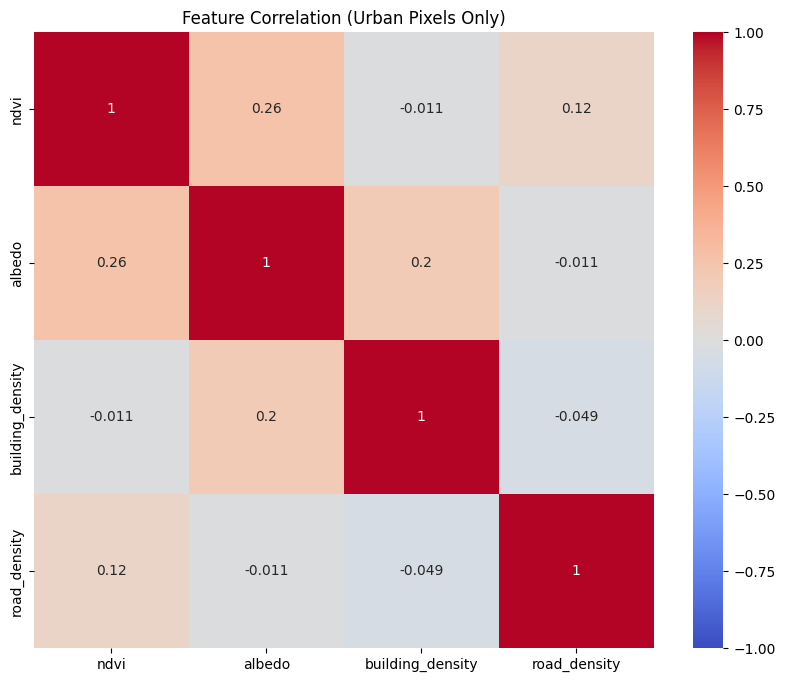

In [9]:
# 4.1 Correlation Matrix (Urban Area)
if 'urban_mask_30m.tif' in stack_arrays:
    urban = stack_arrays['urban_mask_30m.tif'] == 1
    df_corr = pd.DataFrame()
    cont_feats = ['ndvi_30m.tif', 'albedo_30m.tif', 'building_density_30m.tif', 'road_density_30m.tif']
    
    valid_idx = urban
    # Intersect validity
    for f in cont_feats:
        if f in stack_arrays:
            d = stack_arrays[f]
            valid_idx = valid_idx & (d != -9999) & (~np.isnan(d))
            
    for f in cont_feats:
        if f in stack_arrays:
            short_name = f.replace('_30m.tif', '')
            df_corr[short_name] = stack_arrays[f][valid_idx]
            
    if not df_corr.empty:
        plt.figure(figsize=(10, 8))
        sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
        plt.title("Feature Correlation (Urban Pixels Only)")
        plt.show()
    else:
        print("No valid pixels for correlation.")

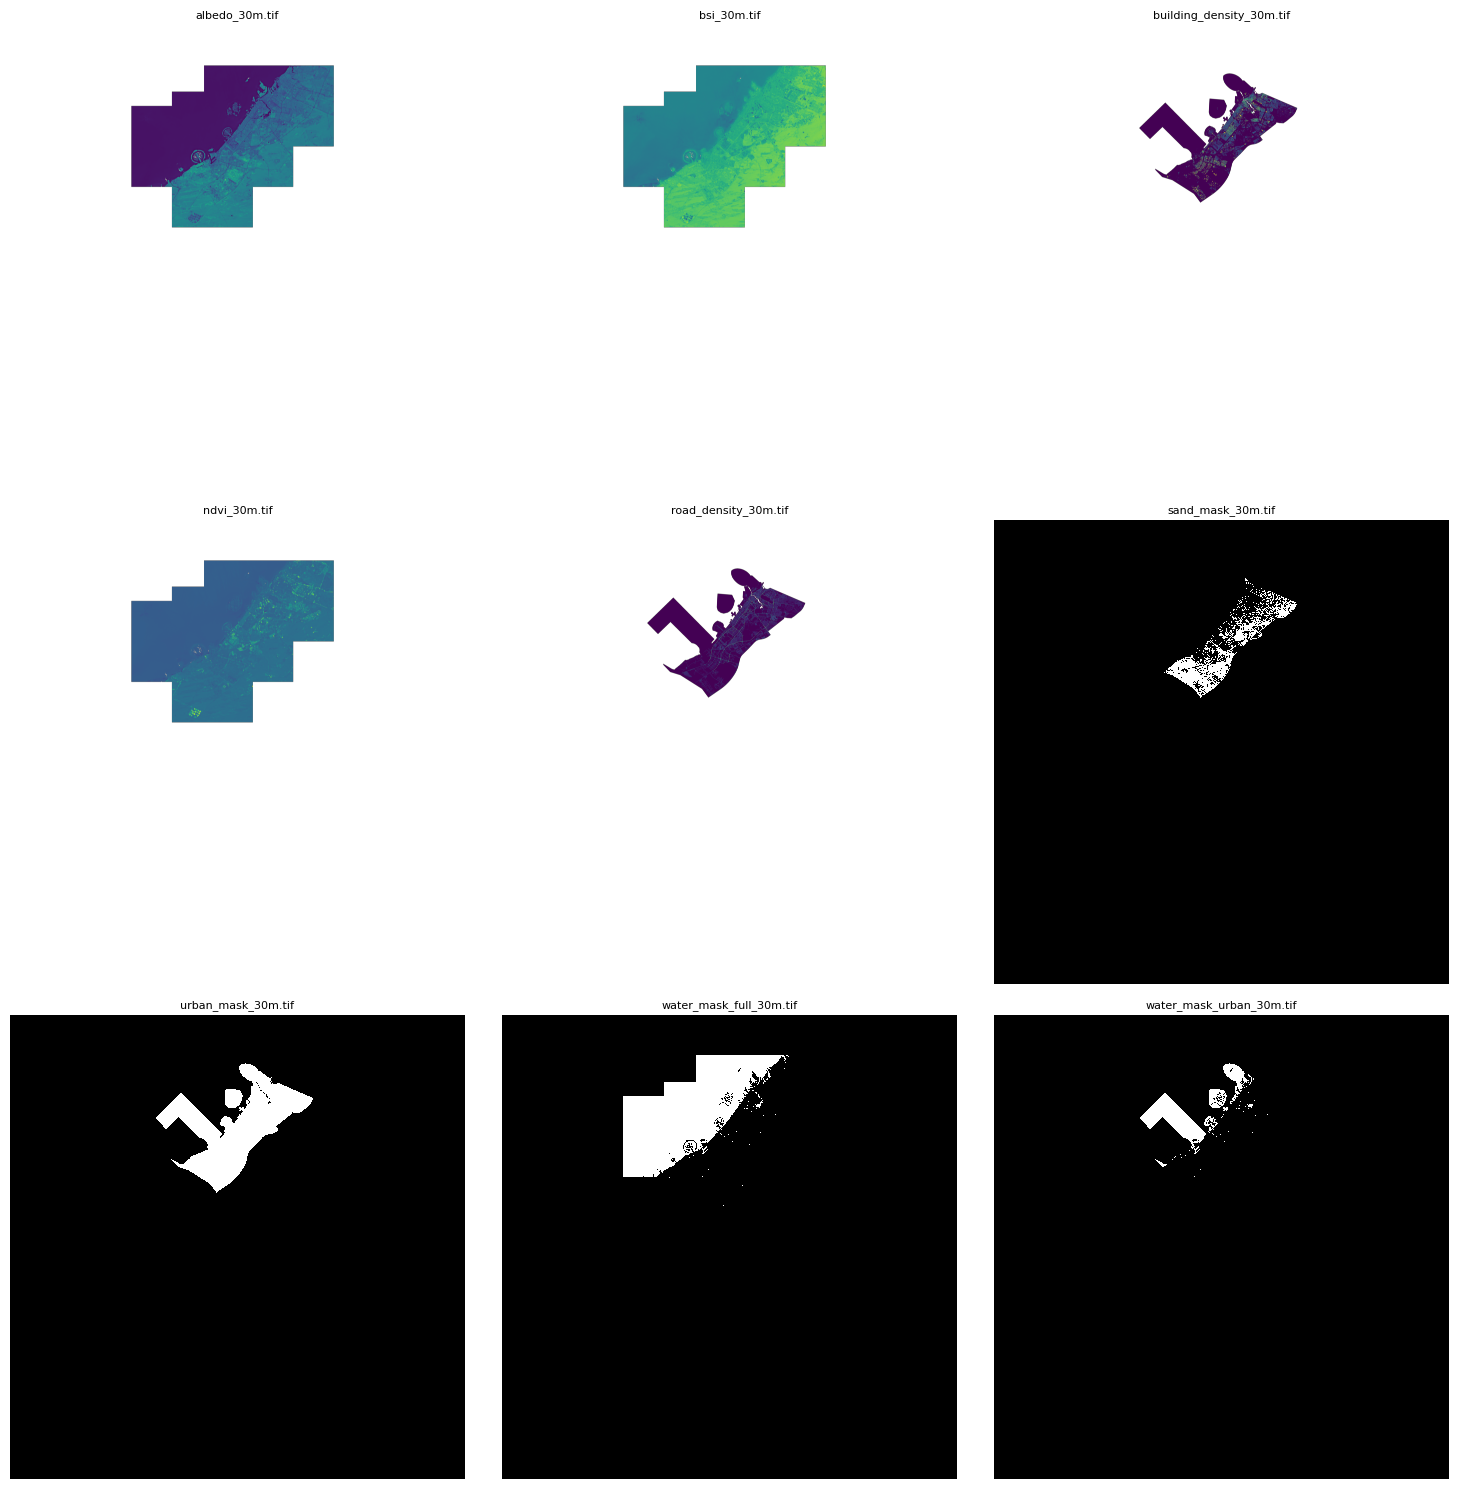

In [10]:
# 4.2 Map Gallery
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for i, f in enumerate(files):
    if i >= len(axes): break
    ax = axes[i]
    name = f.name
    data = stack_arrays[name]
    
    # Handle nodata for plotting
    plot_data = data.astype(float)
    plot_data[plot_data == -9999] = np.nan
    if 'mask' in name:
        im = ax.imshow(plot_data, cmap='gray', interpolation='none')
    else:
        im = ax.imshow(plot_data, cmap='viridis')
        
    ax.set_title(name, fontsize=8)
    ax.axis('off')
    
plt.tight_layout()
plt.show()